In [29]:
%config Completer.use_jedi = False

In [30]:
# load module
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
import copy
import warnings
import torch
import optuna
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, LearningRateMonitor
from pytorch_lightning.loggers import TensorBoardLogger


from pytorch_forecasting import Baseline, TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.metrics import SMAPE, PoissonLoss, QuantileLoss
#from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters

# training error 일때만 풀기
#import tensorflow as tf 
#import tensorboard as tb 
#tf.io.gfile = tb.compat.tensorflow_stub.io.gfile

import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings("ignore")  # avoid printing out absolute paths
plt.rcParams['font.family'] = 'NanumGothic'
#plt.rcParams['font.sans-serif'] = ['NanumGothic.ttf', 'sans-serif']


In [31]:
# functions
def ewma_data_processing(path = '../training_data/ewma_6h_scaling.csv'):
    data = pd.read_csv(path)
    data.drop('Unnamed: 0.1'   , axis=1 , inplace=True)
    data.drop('Unnamed: 0'   , axis=1 , inplace=True)
    data['REG_DTIME'] = pd.to_datetime(data['REG_DTIME'])
    data['DOW'] = data['REG_DTIME'].dt.dayofweek
    data['HOD'] = data['REG_DTIME'].dt.hour
    data["time_idx"] =  \
    (data["REG_DTIME"].dt.month) * data["REG_DTIME"].dt.daysinmonth * 24  + \
    data["REG_DTIME"].dt.day * 24  + \
    data["REG_DTIME"].dt.hour 
    data["time_idx"] -= data["time_idx"].min()
    data['h_dong'] = data['h_dong'].astype(str)
    data['DOW'] = data['DOW'].astype(str)
    data['HOD'] = data['HOD'].astype(str)
    data['precip_form'] = data['precip_form'].astype(str)
    data['isHoliday'] = data['isHoliday'].astype(str)

    return data

def org_data_processing(path = '../sample_table/total_data.csv'):
    data = pd.read_csv(path)
    data.drop('Unnamed: 0'   , axis=1 , inplace=True)
    data['REG_DTIME'] = pd.to_datetime(data['REG_DTIME'])
    data['DOW'] = data['REG_DTIME'].dt.dayofweek
    data['HOD'] = data['REG_DTIME'].dt.hour
    data["time_idx"] =  \
    (data["REG_DTIME"].dt.month) * data["REG_DTIME"].dt.daysinmonth * 24  + \
    data["REG_DTIME"].dt.day * 24  + \
    data["REG_DTIME"].dt.hour 
    data["time_idx"] -= data["time_idx"].min()
    data['h_dong'] = data['h_dong'].astype(str)
    data['DOW'] = data['DOW'].astype(str)
    data['HOD'] = data['HOD'].astype(str)
    data['precip_form'] = data['precip_form'].astype(str)
    data['isHoliday'] = data['isHoliday'].astype(str)

    return data

def get_training(data , max_prediction_length, max_encoder_length):
    # traing data 생성
    max_prediction_length = max_prediction_length
    max_encoder_length = max_encoder_length
    training_cutoff = data["time_idx"].max() - max_prediction_length

    training = TimeSeriesDataSet(
        data[lambda x : x.time_idx <= training_cutoff],
        time_idx = "time_idx",
        target = "count",
        group_ids = ['h_dong'],
        min_encoder_length=max_encoder_length // 2,  # keep encoder length long (as it is in the validation set)
        max_encoder_length=max_encoder_length,
        min_prediction_length=1,
        max_prediction_length=max_prediction_length,
        static_categoricals=["h_dong"],
        time_varying_known_categoricals=["HOD", "DOW" , 'isHoliday'],
        time_varying_known_reals=['pops'],
        #variable_groups={"special_days": special_days},  # group of categorical variables can be treated as one variable
        time_varying_unknown_categoricals=['precip_form'],
        time_varying_unknown_reals=['count','windspd' , 'temp' ,'precip'],
        add_relative_time_idx=True,
        add_target_scales=True,
        add_encoder_length=True,
        #allow_missing=True,
        allow_missing_timesteps = True)
    return training

def truncate(num, rat):
    if (num - int(num)) < rat:
        return int(num)
    else:
        return int(num)+1
    
# boolean으로 계산시에는 call하는 함수에서 categoize
def perf_measure_boolean(y_actual, y_pred):
    # y_actual value
    # y_pred  array
    # numberical measuer
    TP =  FP = TN = FN = 0
    
    if y_actual == 1 and sum(y_pred) > 0:
        TP += 1
    if y_actual == 1 and sum(y_pred) == 0:
        FN += 1
    if y_actual == 0 and sum(y_pred) > 0:
        FP += 1
    if y_actual == 0 and sum(y_pred) == 0:
        TN += 1

    return TP, FN ,FP, TN

def perf_measure_numerial(y_actual, y_pred):
    # y_actual one array
    # y_pred  array
    # numberical measuer : set class로 and 연산
    TP =  FP = TN = FN = 0
    inter = np.intersect1d(y_actual , y_pred)

    if len(y_pred) == 1:
        if y_actual[0] == y_pred[0] and y_actual[0] > 0:
            TP += 1
        if y_actual[0] > 0 and y_actual[0] != y_pred[0]:
            FN += 1
        if y_actual[0] == 0 and y_pred[0] > 0 :
            FP += 1
        if y_actual[0] == y_pred[0] == 0:
            TN += 1

    else:
        if len(inter) == 0:
            if y_actual[0] > 0:
                FN +=1
            if y_actual[0] == 0 and sum(y_pred) > 0:
                FP += 1

                
        if len(inter) == 1:
            if y_actual[0] > 0:
                TP +=1
            if y_actual[0] == 0 and sum(y_pred) > 0:
                FP += 1
            elif y_actual[0] == 0:
                TN += 1
    return TP, FN ,FP, TN 

def boolean(num):
    if num == 0:
        return 0
    else:
        return 1

In [14]:
   
# class : load & training
class TFTmodel():
    def __init__(self, org_data , ewma_data , max_prediction_length, max_encoder_length, bs1, bs2):
        #   data preprocessing
        self.ewma_data = ewma_data_processing(ewma_data)
        self.org_data = org_data_processing(org_data)
        self.org_training = get_training(self.org_data,max_prediction_length, max_encoder_length)
        self.ewma_training = get_training(self.ewma_data,max_prediction_length, max_encoder_length)
        
        batch_size= bs1
        self.org_dataloader = self.org_training.to_dataloader(bs1)
        self.org_validation = TimeSeriesDataSet.from_dataset(self.org_training, self.org_data, predict=True, stop_randomization=True)
        batch_size = bs2  # set this between 32 to 128
        self.org_train_dataloader = self.org_training.to_dataloader(train=True, batch_size=bs2, num_workers=0)
        self.org_val_dataloader = self.org_validation.to_dataloader(train=False, batch_size=bs2*100, num_workers=0)
        
        batch_size= bs1
        self.ewma_dataloader = self.ewma_training.to_dataloader(bs1)
        self.ewma_validation = TimeSeriesDataSet.from_dataset(self.ewma_training, self.ewma_data, predict=True, stop_randomization=True)
        batch_size = bs2  # set this between 32 to 128
        self.ewma_train_dataloader = self.ewma_training.to_dataloader(train=True, batch_size=bs2, num_workers=0)
        self.ewma_val_dataloader = self.ewma_validation.to_dataloader(train=False, batch_size=bs2*100, num_workers=0)
        self.dong_scaling_coff = {}
        for dong in self.org_data['h_dong'].unique():
            self.dong_scaling_coff[dong] = 1
        self.metric_mode = None
    
    def print_hparams(self):
        print(self.tft.hparams)
    
        
    def load_model(self, model_path):
        self.load_model = TemporalFusionTransformer.load_from_checkpoint(model_path)
        
        
    def quantize(self, mode,threshold , q):
        self.rounding = threshold
        if mode == 'load':
            pred ,x ,dong_idx = self.load_model.predict(self.ewma_val_dataloader, return_index = True, mode="raw", 
                                                        return_x = True)
            self.ret_pred_arr = pred
            for i in range(21):
                dong = dong_idx.loc[i]['h_dong']
                pred['prediction'][i,:,q] = (pred['prediction'][i,:,q] - pred['prediction'][i,:,q].min()) * self.dong_scaling_coff[dong]
                
            pred_arr = pred['prediction'][:,:,q]
            
            
            #return pred_arr
            self.dong_idx = dong_idx
            act_arr = self.org_data[self.org_data['time_idx']>= dong_idx['time_idx'].loc[0]]
            # pred _df 
            mins = pred_arr.min()
            pred_df = pd.DataFrame(columns = ['REG_DTIME' , 'h_dong' , 'count'])
            time_line = act_arr['REG_DTIME'].unique()
            pred_df = pd.DataFrame()
            for dong in dong_idx.index:
                dong_nm = dong_idx['h_dong'].loc[dong]
                for idx in range(pred_arr.shape[1]):
                    #print(pred_arr.numpy()[dong][idx])
                    total_idx = dong * pred_arr.shape[1] + idx
                    pred_df.loc[total_idx,'REG_DTIME'] = time_line[idx]
                    pred_df.loc[total_idx,'h_dong'] = dong_nm
                    pred_df.loc[total_idx, 'count'] = truncate(pred_arr.numpy()[dong][idx]   , threshold)
                    
            # act_df
            act_df = act_arr[['REG_DTIME' , 'h_dong' , 'count']]
            act_df.reset_index(inplace=True, drop=True)
            self.ret_pred_arr = pred['prediction']
            return act_df , pred_df 
        
    def confusion_df(self,act_df, pred_df, window_size , mode):
        dts = pd.date_range(act_df['REG_DTIME'].min() , act_df['REG_DTIME'].max(), freq='1h')
        conf_df = pd.DataFrame(columns = ['REG_DTIME', 'h_dong', 'TP' , 'FP', 'TN', 'FN'])
        self.metric_mode = mode
        self.window_size = window_size
        conf_idx = 0
        
        for dong in pred_df['h_dong'].unique():
            dong_act_df = act_df[act_df['h_dong'] == dong]
            dong_pred_df = pred_df[pred_df['h_dong'] == dong]
            dong_act_df.reset_index(inplace=True, drop=True)
            dong_pred_df.reset_index(inplace=True, drop=True)
            if mode == 'category':
                dong_pred_df['count'] = dong_pred_df['count'].apply(lambda x: boolean(x))
                dong_act_df['count'] = dong_act_df['count'].apply(lambda x: boolean(x))
                for idx in dong_act_df.index:
                    if idx-window_size <0:
                        idx_s = 0
                    else:
                        idx_s = idx - window_size                    
                    if idx+window_size > len(dong_act_df.index):
                        idx_e = len(dong_act_df.index)
                    else:
                        idx_e = idx + window_size + 1
                        
                    actual = dong_act_df.loc[idx]['count']
                    pred = dong_pred_df[idx_s : idx_e]['count'].values
                    TP, FN ,FP, TN = perf_measure_boolean(actual, pred)
                    conf_df.loc[conf_idx , 'TP'] = TP
                    conf_df.loc[conf_idx , 'FP'] = FP
                    conf_df.loc[conf_idx , 'TN'] = TN
                    conf_df.loc[conf_idx , 'FN'] = FN
                    conf_df.loc[conf_idx , 'REG_DTIME'] = dong_act_df.loc[idx]['REG_DTIME']
                    conf_df.loc[conf_idx , 'h_dong'] = dong
                    conf_idx += 1  
            
            if mode == 'numerical':
                for idx in dong_act_df.index:
                    if idx-window_size <0:
                        idx_s = 0
                    else:
                        idx_s = idx - window_size                    
                    if idx+window_size > len(dong_act_df.index):
                        idx_e = len(dong_act_df.index)
                    else:
                        idx_e = idx + window_size + 1
                                        
                    actual = dong_act_df.loc[idx]['count']
                    pred = dong_pred_df[idx_s : idx_e]['count'].values
                    TP, FN ,FP, TN = perf_measure_numerial([actual], pred)
                    conf_df.loc[conf_idx , 'TP'] = TP
                    conf_df.loc[conf_idx , 'FP'] = FP
                    conf_df.loc[conf_idx , 'TN'] = TN
                    conf_df.loc[conf_idx , 'FN'] = FN
                    conf_df.loc[conf_idx , 'REG_DTIME'] = dong_act_df.loc[idx]['REG_DTIME']
                    conf_df.loc[conf_idx , 'h_dong'] = dong
                    conf_idx += 1

        self.conf_df = conf_df
        return conf_df
            
    def all_dong_plot(self, act_df, pred_df, start, end):
        for dong in self.ewma_data['h_dong'].unique():
            self.dong_plot(dong, act_df, pred_df, start, end)
        
    def dong_plot(self, dong , act_df, pred_df, start, end):
        if dong not in act_df['h_dong'].unique():
            return f'{dong} is not in DataFrame'
        # 하나의 dong 기준으로 예측값과 실제값 비교`
        act_df = act_df[act_df['h_dong'] == dong]
        pred_df = pred_df[pred_df['h_dong'] == dong]
        time_idx = pd.date_range(start, end , freq='1h')
        act_df = act_df[act_df['REG_DTIME'].isin(time_idx)]
        pred_df = pred_df[pred_df['REG_DTIME'].isin(time_idx)]
        
        plt.figure()
        plt.scatter(time_idx, act_df['count'], label= 'act_count')
        plt.scatter(time_idx, pred_df['count'], label = 'pred_count')
        plt.title(f'{dong}_count {start} ~ {end}')
        plt.legend()        
        pass
    
                
    def pred_plot(self,q):
        pred ,x ,dong_idx = self.load_model.predict(self.ewma_val_dataloader, return_index = True, mode="raw", return_x = True)
        f , axes = plt.subplots(7,3 , figsize=(14,25))
        max_list = []
    
        for i in range(21):
            dong_nm = dong_idx['h_dong'].loc[i]
            axes[i//3 , i - (i//3)*3].set_title(f'{dong_nm} prediction')
            axes[i//3 , i - (i//3)*3].plot((pred['prediction'][i,:,q] - pred['prediction'][i,:,q].min()))
            max_list.append(max(pred['prediction'][i,:,q] - pred['prediction'][i,:,q].min()).float())
            #axes[i//3 , i - (i//3)*3].axhline(self.rounding, 0, 720 , color='lightgray', linestyle='--', linewidth=2)
            #axes[i//3 , i - (i//3)*3].axhline(0.9 , 0, 720 , color='lightgray', linestyle='--', linewidth=2)
        self.pred_arr = pred
        min_idx = np.argmin(max_list)
        max_idx = np.argmax(max_list)
        print(min_idx, max_idx)
        axes[min_idx//3 , min_idx - (min_idx//3)*3].set_title(f'{dong_nm} prediction in Mix')
        axes[max_idx//3 , max_idx - (max_idx//3)*3].set_title(f'{dong_nm} prediction in Max')
        axes[min_idx//3 , min_idx - (min_idx//3)*3].plot((pred['prediction'][min_idx,:,q] - pred['prediction'][min_idx,:,q].min()), color='limegreen')
        axes[max_idx//3 , max_idx - (max_idx//3)*3].plot((pred['prediction'][max_idx,:,q] - pred['prediction'][max_idx,:,q].min()), color='violet')

        
        self.dong_idx = dong_idx
        plt.show()
        
    def actual_plot(self):
        pred ,x ,dong_idx = self.load_model.predict(self.ewma_val_dataloader, return_index = True, mode="raw", return_x = True)
        act_arr = self.org_data[self.org_data['time_idx']>= dong_idx['time_idx'].loc[0]]
        act_df = act_arr[['REG_DTIME' , 'h_dong' , 'count']]
        act_df.reset_index(inplace=True, drop=True)
        
        f , axes = plt.subplots(7,3 , figsize=(14,25))
        for i, dong in enumerate(act_df['h_dong'].unique()):
            #print(i ,dong)
            axes[i//3 , i - (i//3)*3].set_title(f'{dong} prediction')
            dong_df = act_df[act_df['h_dong'] == dong]
            dong_df.reset_index(inplace=True, drop=True)
            axes[i//3 , i - (i//3)*3].plot(dong_df['count'])
            
        plt.show()


In [24]:
org_data   = '../../training_data/total_data.csv'
ewma_data  = '../../training_data/ewma_6h_scaling.csv'
start = '2021/12/2'
end = '2021/12/3'
model_path = 'test/lightning_logs/version_22/checkpoints/epoch=99-step=500.ckpt'
window_size = 0

In [34]:
xyz = pd.read_csv('../../training_data/ewma_6h_scaling.csv')

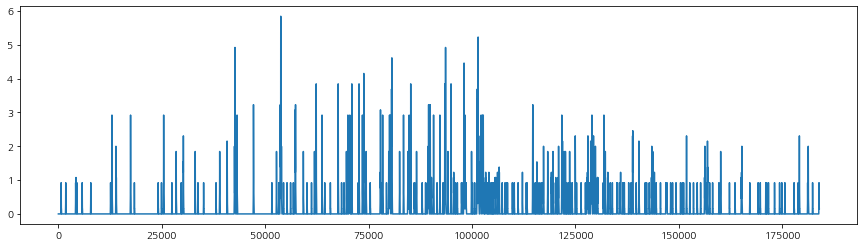

In [40]:
plt.figure(figsize=(15,4))
plt.plot(xyz[xyz['h_dong'] == '강남동']['count'])

In [25]:
TFTclass = TFTmodel(org_data, ewma_data, 24*30 , 24*30*3, 4, 16)
TFTclass.load_model(model_path)

17 18


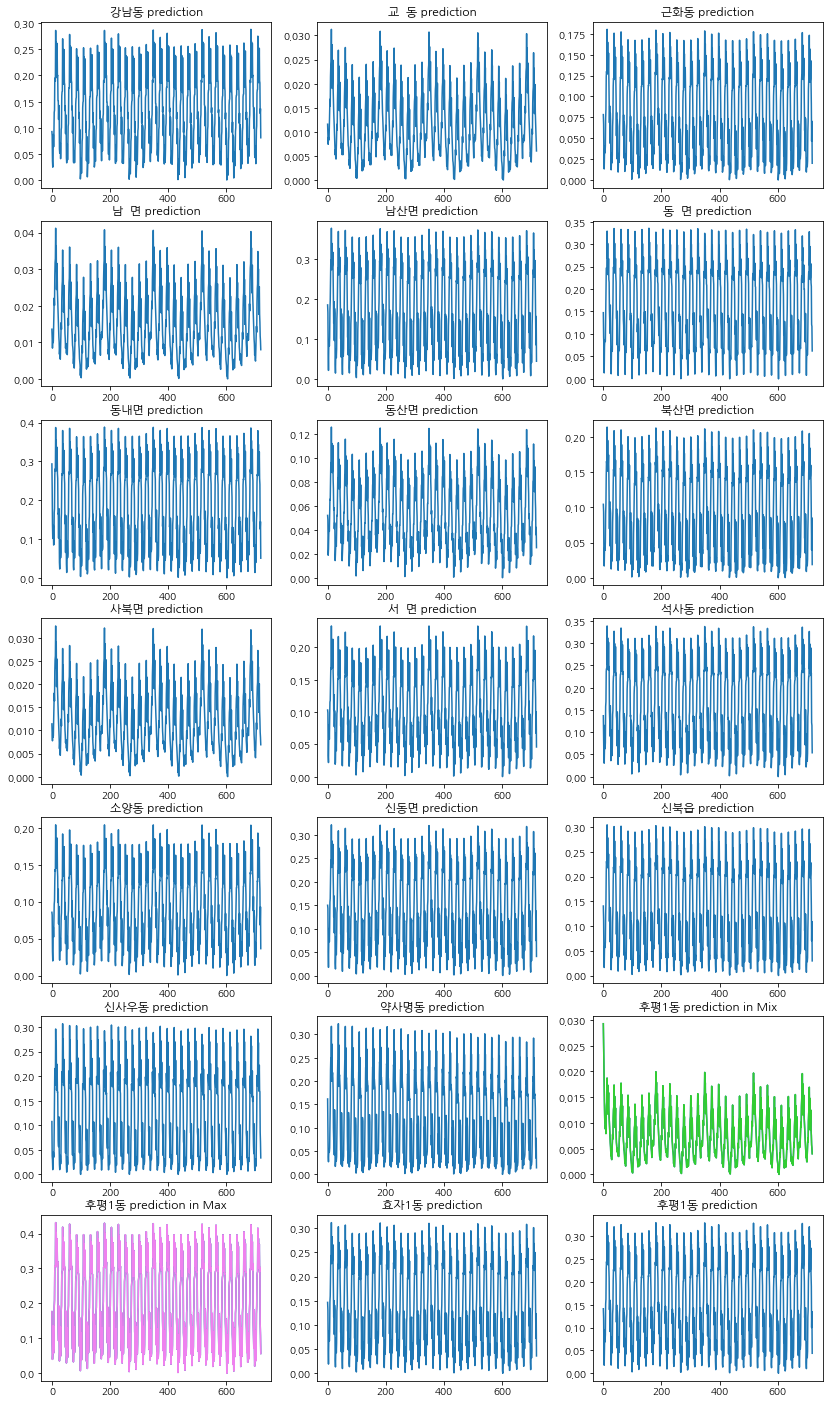

In [26]:
TFTclass.pred_plot(5)

17 18


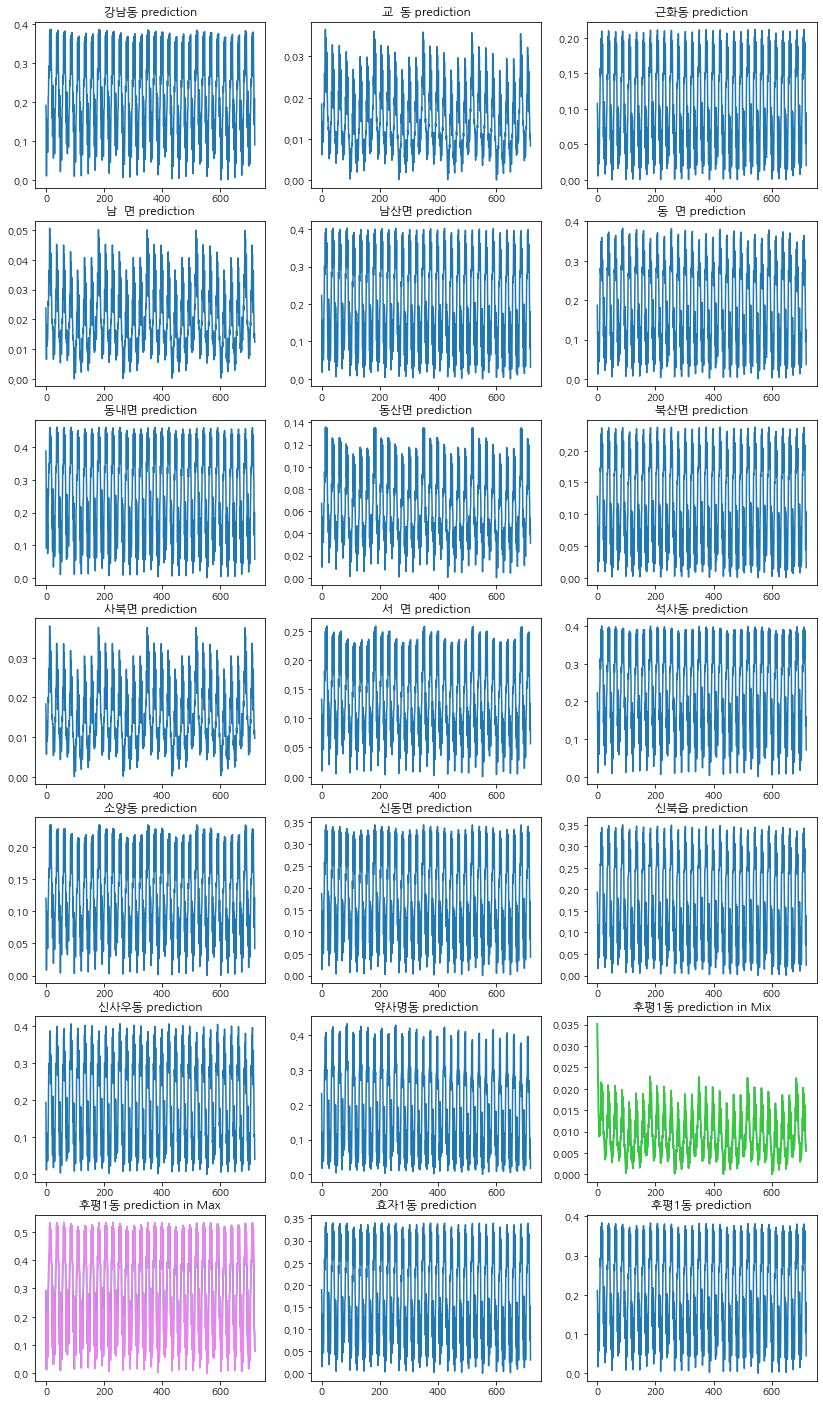

In [27]:
TFTclass.pred_plot(6)